In [75]:
import numpy as np
from scipy.optimize import root_scalar, minimize_scalar
from scipy.stats import norm

In [140]:
sigmas = np.arange(1, 10) / .5
mu = 0

In [141]:
xs = np.array([norm(loc=mu, scale=sigma).rvs() for sigma in sigmas])

In [142]:
def hacer_g(xs):
    def _g(mu):
        return sum(1 / (xs - mu))
    return _g

In [143]:
g = hacer_g(xs)
g(min(xs) - 0.1)

10.759585865380739

In [144]:
import matplotlib.pyplot as plt

In [188]:
xmin, xmax = min(xs), max(xs)
margen = 0.05
sop = np.linspace(xmin - (xmax - xmin) * margen, xmax + (xmax - xmin) * margen, 2000)
sop_plus = np.concatenate([sop, xs + 1e-5, xs - 1e-5])
sop_plus.sort()

In [190]:
img = np.vectorize(g)(sop_plus)

In [191]:
x1, x2 = xs[xs.argsort()][:2]

In [192]:
sol = root_scalar(g, bracket=(x1 + 1e-5, x2 - 1e-5))

In [193]:
g(sol.root)

1.457167719820518e-14

In [198]:
g(-np.inf), g(np.inf)

(0.0, 0.0)

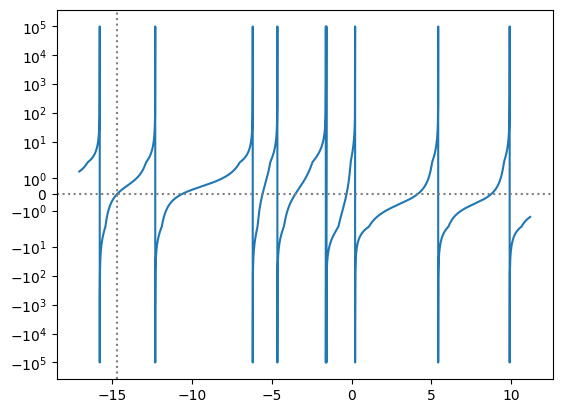

In [195]:
plt.plot(sop_plus, img)
plt.yscale("symlog")
plt.axhline(0, color="gray", linestyle="dotted")
plt.axvline(sol.root, color="gray", linestyle="dotted")